# Load Data

In [1]:
import pandas as pd
import missingno as msno
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Path to FRED data folder relative to your notebooks working directory
fred_data_dir = Path("..") / "data" / "raw" / "fred_data"

# Directly load the known files
md = pd.read_csv(fred_data_dir / "transf_md.csv")
qd = pd.read_csv(fred_data_dir / "transf_qd.csv")

In [3]:
# Convert the 'date' columns to datetime format
md['date'] = pd.to_datetime(md['date'])
qd['date'] = pd.to_datetime(qd['date'])

# Print start and end dates for each dataset
print("Monthly data range:")
print("Start:", md['date'].min())
print("End  :", md['date'].max())

print("\nQuarterly data range:")
print("Start:", qd['date'].min())
print("End  :", qd['date'].max())

Monthly data range:
Start: 1959-01-01 00:00:00
End  : 2025-03-01 00:00:00

Quarterly data range:
Start: 1959-03-01 00:00:00
End  : 2025-03-01 00:00:00


In [4]:
# Set date as index
md = md.set_index('date').sort_index()

# Create a complete monthly date range from start to end
full_month_range = pd.date_range(start=md.index.min(), end=md.index.max(), freq='MS')

# Compare with existing dates
missing_months = full_month_range.difference(md.index)

print("Missing monthly dates:")
print(missing_months)


Missing monthly dates:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [5]:
# For qd: assumes 'date' is datetime and qd is sorted by date
qd = qd.set_index('date').sort_index()

# Create quarterly dates using '03-01', '06-01', etc.
full_quarters = pd.date_range(start=qd.index.min(), end=qd.index.max(), freq='3MS')

# Find missing quarterly periods
missing_quarters = full_quarters.difference(qd.index)

print("Missing quarterly dates:")
print(missing_quarters)


Missing quarterly dates:
DatetimeIndex([], dtype='datetime64[ns]', freq='3MS')


As target quarterly candidates i think we can start with:
INDPRO (column G), CPIAUCSL (col DR), or PCEPI (col CT), and UNRATE (col BI)
I added pdf called Fred-md updated appendix to the joint folder (Attention MIDAS -> fred data) 
It has decription of all transformation codes and brief series decriptions as well

After our meeting, we agreed we should try something like Y (industrial production INTPROD quarterly) - X something monthly (a subset).

In [6]:
qd.columns

Index(['Unnamed: 0', 'GDPC1', 'PCECC96', 'PCDGx', 'PCESVx', 'PCNDx', 'GPDIC1',
       'FPIx', 'Y033RC1Q027SBEAx', 'PNFIx',
       ...
       'TNWMVBSNNCBBDIx', 'TLBSNNBx', 'TLBSNNBBDIx', 'TABSNNBx', 'TNWBSNNBx',
       'TNWBSNNBBDIx', 'CNCFx', 'S&P 500', 'S&P div yield', 'S&P PE ratio'],
      dtype='object', length=246)

In [7]:
md.columns

Index(['Unnamed: 0', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx',
       'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD',
       ...
       'DNDGRG3M086SBEA', 'DSERRG3M086SBEA', 'CES0600000008', 'CES2000000008',
       'CES3000000008', 'UMCSENTx', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST',
       'VIXCLSx'],
      dtype='object', length=127)

Monthly Data Missingness:


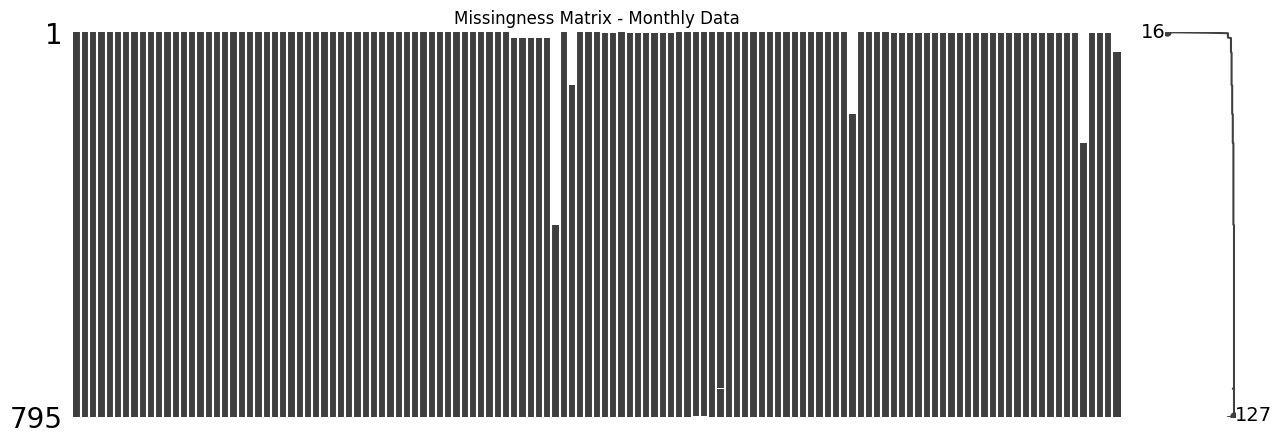

In [8]:
# Monthly: missingness matrix
print("Monthly Data Missingness:")
msno.matrix(md, figsize=(15, 5), sparkline=True)
plt.title("Missingness Matrix - Monthly Data")
plt.show()

Quarterly Data Missingness:


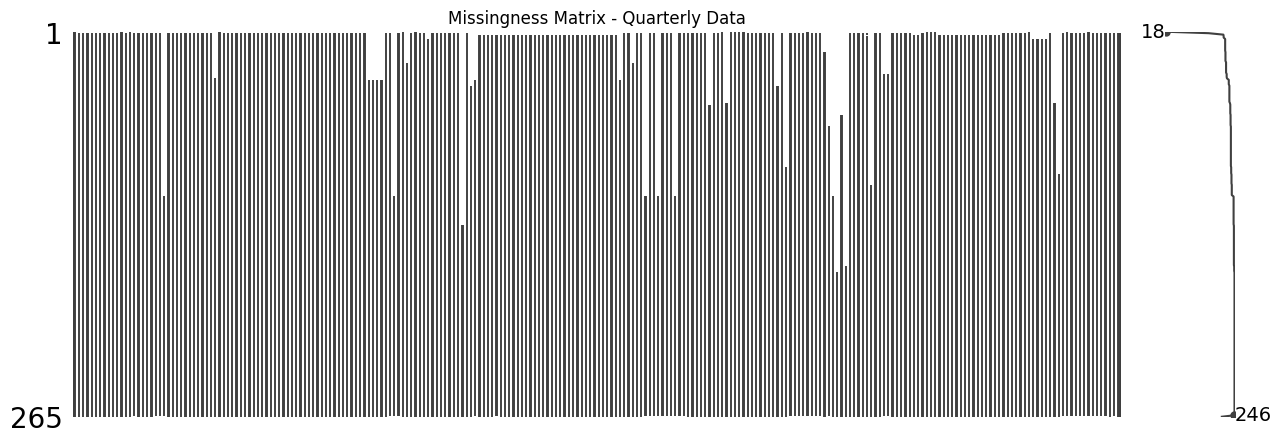

In [9]:
# Quarterly: missingness matrix
print("Quarterly Data Missingness:")
msno.matrix(qd, figsize=(15, 5), sparkline=True)
plt.title("Missingness Matrix - Quarterly Data")
plt.show()

In [18]:
# Remove 'Unnamed: 0' and 'date' from comparison
md_vars = set(md.columns) - {'Unnamed: 0', 'date'}
qd_vars = set(qd.columns) - {'Unnamed: 0', 'date'}

# Print initial sizes
print(f"Total variables in MD: {len(md_vars)}")
print(f"Total variables in QD: {len(qd_vars)}")

# Compare
common_vars = md_vars & qd_vars
print(f"Variables in both MD and QD ({len(common_vars)}):")
print(sorted(common_vars))

only_in_md = md_vars - qd_vars
print(f"\nVariables only in MD ({len(only_in_md)}):")
print(sorted(only_in_md))

only_in_qd = qd_vars - md_vars
print(f"\nVariables only in QD ({len(only_in_qd)}):")
print(sorted(only_in_qd))


Total variables in MD: 126
Total variables in QD: 245
Variables in both MD and QD (96):
['AAA', 'AAAFFM', 'AMDMNOx', 'AMDMUOx', 'ANDENOx', 'AWHMAN', 'AWOTMAN', 'BAA', 'BUSINVx', 'CE16OV', 'CES0600000007', 'CES0600000008', 'CLAIMSx', 'CMRMTSPLx', 'CPIAPPSL', 'CPIAUCSL', 'CPIMEDSL', 'CPITRNSL', 'CPIULFSL', 'CUMFNS', 'CUSR0000SA0L2', 'CUSR0000SA0L5', 'CUSR0000SAC', 'CUSR0000SAD', 'CUSR0000SAS', 'DMANEMP', 'DTCOLNVHFNM', 'DTCTHFNM', 'EXCAUSx', 'EXJPUSx', 'EXSZUSx', 'EXUSUKx', 'FEDFUNDS', 'GS1', 'GS10', 'GS5', 'HOUST', 'HOUSTMW', 'HOUSTNE', 'HOUSTS', 'HOUSTW', 'INDPRO', 'INVEST', 'IPB51222S', 'IPBUSEQ', 'IPCONGD', 'IPDCONGD', 'IPDMAT', 'IPFINAL', 'IPFUELS', 'IPMANSICS', 'IPMAT', 'IPNCONGD', 'IPNMAT', 'ISRATIOx', 'M2REAL', 'MANEMP', 'NDMANEMP', 'NONBORRES', 'OILPRICEx', 'PAYEMS', 'PERMIT', 'PERMITMW', 'PERMITNE', 'PERMITS', 'PERMITW', 'PPICMM', 'S&P 500', 'S&P PE ratio', 'S&P div yield', 'SRVPRD', 'T5YFFM', 'TB3MS', 'TB3SMFFM', 'TB6MS', 'TOTRESNS', 'TWEXAFEGSMTHx', 'UEMP15T26', 'UEMP27OV', '

In [20]:
qd_vars

{'A014RE1Q156NBEA',
 'A823RL1Q225SBEA',
 'AAA',
 'AAAFFM',
 'ACOGNOx',
 'AHETPIx',
 'AMDMNOx',
 'AMDMUOx',
 'ANDENOx',
 'AWHMAN',
 'AWHNONAG',
 'AWOTMAN',
 'B020RE1Q156NBEA',
 'B021RE1Q156NBEA',
 'BAA',
 'BAA10YM',
 'BOGMBASEREALx',
 'BUSINVx',
 'BUSLOANSx',
 'CE16OV',
 'CES0600000007',
 'CES0600000008',
 'CES2000000008x',
 'CES3000000008x',
 'CES9091000001',
 'CES9092000001',
 'CES9093000001',
 'CIVPART',
 'CLAIMSx',
 'CMRMTSPLx',
 'CNCFx',
 'COMPAPFF',
 'COMPRMS',
 'COMPRNFB',
 'CONSPIx',
 'CONSUMERx',
 'CP3M',
 'CPF3MTB3Mx',
 'CPIAPPSL',
 'CPIAUCSL',
 'CPILFESL',
 'CPIMEDSL',
 'CPITRNSL',
 'CPIULFSL',
 'CUMFNS',
 'CUSR0000SA0L2',
 'CUSR0000SA0L5',
 'CUSR0000SAC',
 'CUSR0000SAD',
 'CUSR0000SAS',
 'CUSR0000SEHC',
 'DCLORG3Q086SBEA',
 'DDURRG3Q086SBEA',
 'DFDHRG3Q086SBEA',
 'DFSARG3Q086SBEA',
 'DFXARG3Q086SBEA',
 'DGDSRG3Q086SBEA',
 'DGOERG3Q086SBEA',
 'DHCERG3Q086SBEA',
 'DHLCRG3Q086SBEA',
 'DHUTRG3Q086SBEA',
 'DIFSRG3Q086SBEA',
 'DMANEMP',
 'DMOTRG3Q086SBEA',
 'DNDGRG3Q086SBEA',
 'DO

In [11]:
md[['CPIAUCSL', 'PCEPI', 'UNRATE']].head(20)

,CPIAUCSL,PCEPI,UNRATE
date,,,
1959-01-01,NaN,NaN,NaN
1959-02-01,NaN,NaN,-0.1
1959-03-01,-0.000690,-0.000330,-0.3
1959-04-01,0.001380,0.001315,-0.4
1959-05-01,0.001723,-0.001448,-0.1
1959-06-01,0.000339,0.002360,-0.1
1959-07-01,-0.001034,-0.000792,0.1
1959-08-01,-0.000345,-0.000657,0.1
1959-09-01,0.001367,0.001170,0.3


In [12]:
monthly_vars = ['CPIAUCSL', 'PCEPI', 'UNRATE']
quarterly_vars = ['INDPRO']

# Extract available columns (excluding metadata)
md_vars = set(md.columns) - {'Unnamed: 0', 'date'}
qd_vars = set(qd.columns) - {'Unnamed: 0', 'date'}

# Check each variable
print("Monthly variable availability:")
for var in monthly_vars:
    in_md = var in md_vars
    in_qd = var in qd_vars
    print(f"{var}: {'present in MD' if in_md else 'not in MD'} | {'present in QD' if in_qd else 'not in QD'}")

print("\nQuarterly variable availability:")
for var in quarterly_vars:
    in_md = var in md_vars
    in_qd = var in qd_vars
    print(f"{var}: {'present in MD' if in_md else 'not in MD'} | {'present in QD' if in_qd else 'not in QD'}")


Monthly variable availability:
CPIAUCSL: present in MD | present in QD
PCEPI: present in MD | not in QD
UNRATE: present in MD | present in QD

Quarterly variable availability:
INDPRO: present in MD | present in QD


In [13]:
def create_long_format_FRED(md_path: Path, qd_path: Path, monthly_vars: list, quarterly_vars: list) -> pd.DataFrame:
    """
    Transforms selected monthly and quarterly variables into a unified long-format DataFrame,
    preserving natural frequencies and ordering quarterly entries after monthly ones on the same date.

    Parameters:
        md_path (Path): path to the transformed monthly CSV
        qd_path (Path): path to the transformed quarterly CSV
        monthly_vars (list): list of variable names to extract from monthly data
        quarterly_vars (list): list of variable names to extract from quarterly data

    Returns:
        pd.DataFrame: long-format DataFrame with columns: Timestamp, Variable, Value, Frequency (M or Q)
    """

    # Load datasets
    md = pd.read_csv(md_path, parse_dates=['date'])
    qd = pd.read_csv(qd_path, parse_dates=['date'])

    # Filter and drop missing independently
    md_filtered = md[['date'] + monthly_vars].dropna(subset=monthly_vars)
    qd_filtered = qd[['date'] + quarterly_vars].dropna(subset=quarterly_vars)

    # Melt into long format
    md_long = md_filtered.melt(id_vars='date', var_name='Variable', value_name='Value')
    qd_long = qd_filtered.melt(id_vars='date', var_name='Variable', value_name='Value')

    # Tag frequencies
    md_long['Frequency'] = 'M'
    qd_long['Frequency'] = 'Q'

    # Combine and rename
    long_df = pd.concat([md_long, qd_long], ignore_index=True)
    long_df.rename(columns={'date': 'Timestamp'}, inplace=True)

    # Ensure M comes before Q for the same timestamp
    freq_order = {'M': 0, 'Q': 1}
    long_df['FreqSort'] = long_df['Frequency'].map(freq_order)

    long_df = long_df.sort_values(['Timestamp', 'FreqSort']).drop(columns='FreqSort').reset_index(drop=True)

    return long_df


In [15]:
base_path = Path("..") / "data" / "raw" / "fred_data"
md_path = base_path / "transf_md.csv"
qd_path = base_path / "transf_qd.csv"

# Specify the variable names you want to extract
monthly_vars = ['CPIAUCSL', 'PCEPI', 'UNRATE']
quarterly_vars = ['INDPRO']

# Generate the long-format DataFrame
long_df = create_long_format_FRED(md_path, qd_path, monthly_vars, quarterly_vars)

long_df.head()

,Timestamp,Variable,Value,Frequency
0,1959-03-01,CPIAUCSL,-0.000690,M
1,1959-03-01,PCEPI,-0.000330,M
2,1959-03-01,UNRATE,-0.300000,M
3,1959-04-01,CPIAUCSL,0.001380,M
4,1959-04-01,PCEPI,0.001315,M


In [ ]:
long_df.head(20)

In [ ]:
# Count number of entries by frequency
frequency_counts = long_df['Variable'].value_counts()

print("Frequency counts:")
print(frequency_counts)


In [ ]:
qd['CPIAUCSL'].plot()

In [ ]:
md.columns

# Correlation Analysis

In [5]:
from sklearn.decomposition import PCA

In [2]:
# Path to FRED data folder relative to your notebooks working directory
fred_data_dir = Path("..") / "data" / "raw" / "fred_data"

# Directly load the known files
md = pd.read_csv(fred_data_dir / "transf_md.csv")
qd = pd.read_csv(fred_data_dir / "transf_qd.csv")

In [6]:
# # 2. Define Appendix E.10 variable sets
# monthly_list = {
#     'AAA','AAAFFM','AWOTMAN','BOGMBASE','BUSLOANS','CE16OV','CES0600000008',
#     'CES1021000001','CES2000000008','CES3000000008','CLAIMSx','CLF16OV','CP3Mx',
#     'CPIAPPSL','CPIAUCSL','CPIMEDSL','CPITRNSL','CPIULFSL','CUSR0000SAC',
#     'CUSR0000SAD','CUSR0000SAS','CUSR0000SA0L2','CUSR0000SA0L5','DDURRG3M086SBEA',
#     'DMANEMP','DNDGRG3M086SBEA','DPCERA3M086SBEA','DSERRG3M086SBEA','DTCTHFNM',
#     'EXJPUSx','EXSZUSx','EXUSUKx','FEDFUNDS','GS1','GS5','GS10','HOUST','IPCONGD',
#     'IPDCONGD','IPDMAT','IPFINAL','IPFUELS','IPBUSEQ','IPMAT','IPNMAT','IPMANSICS',
#     'IPB51222S','CUMFNS','M1SL','M2SL','M2REAL','TOTRESNS','INVEST','NONREVSL',
#     'REALLN','PAYEMS','PCEPI','PPICMM','RPI','SRVPRD','TB3MS','TB3SMFFM','TB6MS',
#     'TB6SMFFM','T1YFFM','T5YFFM','T10YFFM','UNRATE','USGOOD','USCONS','USFIRE',
#     'USGOVT','USTPU','USTRADE','USWTRADE','UEMPMEAN','W875RX1','WPSFD49207',
#     'WPSFD49502','WPSID61','WPSID62'
# }

# quarterly_list = {
#     'GDPC1','PCECC96','PCDGx','PCESVx','PCNDx','GPDIC1','FPIx','Y033RC1Q027SBEAx',
#     'TNWMVBSNNCBBDIx','TLBSNNBx','TLBSNNBBDIx','TABSNNBx','TNWBSNNBx','TNWBSNNBBDIx',
#     'CNCFx','S&P 500','S&P div yield','S&P PE ratio'
# }

# # 3. Cross-match your columns
# md_vars = set(md.columns) - {'Unnamed: 0', 'date'}
# qd_vars = set(qd.columns) - {'Unnamed: 0', 'date'}

# md_in_set  = sorted(md_vars & monthly_list)
# md_out_set = sorted(md_vars - monthly_list)
# qd_in_set  = sorted(qd_vars & quarterly_list)
# qd_out_set = sorted(qd_vars - quarterly_list)

# print("Monthly columns IN Appendix list:", md_in_set)
# print("Monthly columns NOT in Appendix list:", md_out_set)
# print("Quarterly columns IN Appendix list:", qd_in_set)
# print("Quarterly columns NOT in Appendix list:", qd_out_set)

In [19]:
# 3. Prepare numeric matrices (drop index/date columns, keep only numeric, drop NaN rows)
md_numeric = (
    md
    .drop(columns=["Unnamed: 0", "date"], errors="ignore")
    .select_dtypes(include="number")
    .dropna(axis=1)
)
qd_numeric = (
    qd
    .drop(columns=["Unnamed: 0", "date"], errors="ignore")
    .select_dtypes(include="number")
    .dropna(axis=1)
)

# 4. Run PCA on the monthly block
pca_md = PCA(n_components=min(md_numeric.shape))
pca_md.fit(md_numeric)

# 4a. Explained variance ratio
ev_md = pd.Series(
    pca_md.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca_md.explained_variance_ratio_))],
    name="explained_variance_ratio"
)

# 4b. Component loadings
loadings_md = pd.DataFrame(
    pca_md.components_.T,
    index=md_numeric.columns,
    columns=ev_md.index
)

# 5. Run PCA on the quarterly block
pca_qd = PCA(n_components=min(qd_numeric.shape))
pca_qd.fit(qd_numeric)

# 5a. Explained variance ratio
ev_qd = pd.Series(
    pca_qd.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca_qd.explained_variance_ratio_))],
    name="explained_variance_ratio"
)

# 5b. Component loadings
loadings_qd = pd.DataFrame(
    pca_qd.components_.T,
    index=qd_numeric.columns,
    columns=ev_qd.index
)

In [21]:
# 6. Display or save results
print("=== Monthly PCA Explained Variance ===")
print(ev_md.head(10))        # top 10 PCs
print("\n=== Monthly PCA Loadings (abs, top 10 on PC1) ===")
print(loadings_md["PC1"].abs().sort_values(ascending=False).head(10))

print("\n=== Quarterly PCA Explained Variance ===")
print(ev_qd.head(10))
print("\n=== Quarterly PCA Loadings (abs, top 10 on PC1) ===")
print(loadings_qd["PC1"].abs().sort_values(ascending=False).head(10))

# 7. Suggest variables to keep (e.g. abs loading > 0.3 on PC1 or PC2)
t= 0.01
md_keep = loadings_md[
    (loadings_md["PC1"].abs() > t) |
    (loadings_md["PC2"].abs() > t)
].index.tolist()

qd_keep = loadings_qd[
    (loadings_qd["PC1"].abs() > t) |
    (loadings_qd["PC2"].abs() > t)
].index.tolist()

print("\nSuggested monthly variables to keep:", md_keep)
print("Suggested quarterly variables to keep:", qd_keep)

=== Monthly PCA Explained Variance ===
PC1     0.807410
PC2     0.074067
PC3     0.063985
PC4     0.025924
PC5     0.012385
PC6     0.005995
PC7     0.003778
PC8     0.002576
PC9     0.001200
PC10    0.001041
Name: explained_variance_ratio, dtype: float64

=== Monthly PCA Loadings (abs, top 10 on PC1) ===
BAAFFM      0.554403
AAAFFM      0.537020
T10YFFM     0.450933
T5YFFM      0.362063
T1YFFM      0.158988
TB6SMFFM    0.152928
TB3SMFFM    0.134142
HOUSTNE     0.029745
AWHMAN      0.025724
HOUSTMW     0.024739
Name: PC1, dtype: float64

=== Quarterly PCA Explained Variance ===
PC1     9.999763e-01
PC2     1.444698e-05
PC3     7.556993e-06
PC4     1.217898e-06
PC5     1.768588e-07
PC6     1.306322e-07
PC7     6.306057e-08
PC8     4.426768e-08
PC9     3.432861e-08
PC10    1.590014e-08
Name: explained_variance_ratio, dtype: float64

=== Quarterly PCA Loadings (abs, top 10 on PC1) ===
HWIx               1.000000
GS10TB3Mx          0.000203
CUMFNS             0.000179
AWHMAN             0.

# Monthly - Quarterly check

In [27]:
import pandas as pd
# Path to FRED data folder relative to your notebooks working directory
fred_data_dir = Path("..") / "data" / "raw" / "fred_data"

# Directly load the known files
md = pd.read_csv(fred_data_dir / "transf_md.csv")
qd = pd.read_csv(fred_data_dir / "transf_qd.csv")

# Convert 'date' to datetime
md['date'] = pd.to_datetime(md['date'])
qd['date'] = pd.to_datetime(qd['date'])

# Identify common variables
md_vars = set(md.columns) - {'Unnamed: 0', 'date'}
qd_vars = set(qd.columns) - {'Unnamed: 0', 'date'}
common_vars = sorted(md_vars & qd_vars)



# Compare values of each common variable at quarterly dates
results = []
for var in common_vars:
    merged = pd.merge(
        md[['date', var]],
        qd[['date', var]],
        on='date',
        suffixes=('_md', '_qd')
    ).dropna()

    mismatches = (merged[f'{var}_md'].round(6) != merged[f'{var}_qd'].round(6)).sum()
    total = len(merged)
    pct_match = 100 * (1 - mismatches / total) if total > 0 else None

    results.append({
        'variable': var,
        'n_obs': total,
        'n_mismatches': mismatches,
        'pct_match': round(pct_match, 2) if pct_match is not None else None
    })

md.set_index('date',inplace=True)
qd.set_index('date',inplace=True)

# Display as DataFrame
results_df = pd.DataFrame(results).sort_values('pct_match')
print(results_df)

         variable  n_obs  n_mismatches  pct_match
1          AAAFFM    265           265       0.00
2         AMDMNOx    264           264       0.00
3         AMDMUOx    264           264       0.00
4         ANDENOx    228           228       0.00
11  CES0600000008    263           263       0.00
..            ...    ...           ...        ...
32       FEDFUNDS    264           257       2.65
54       ISRATIOx    263           253       3.80
83         UNRATE    264           249       5.68
6         AWOTMAN    264           242       8.33
5          AWHMAN    265           231      12.83

[96 rows x 4 columns]


In [24]:
len(common_vars)

96

In [35]:
merged

,date,WPSID62_md,WPSID62_qd
2,1959-09-01,0.016218,-0.020310
3,1959-12-01,-0.000043,0.008358
4,1960-03-01,0.009820,0.011951
5,1960-06-01,-0.013072,0.005451
6,1960-09-01,0.026623,-0.025210
...,...,...,...
260,2024-03-01,-0.009655,0.000298
261,2024-06-01,0.007492,0.035032
262,2024-09-01,0.012550,-0.017790
263,2024-12-01,0.028822,0.013100


In [29]:
qd['AAAFFM']

date
1959-03-01    1.5600
1959-06-01    1.2700
1959-09-01    0.8967
1959-12-01    0.5800
1960-03-01    0.6200
               ...  
2024-03-01   -0.3600
2024-06-01   -0.1100
2024-09-01   -0.3733
2024-12-01    0.4433
2025-03-01    1.0267
Name: AAAFFM, Length: 265, dtype: float64

In [36]:
qd.shape

(265, 246)

In [37]:
md.shape

(795, 127)

In [76]:
# Clean up column names
md_vars = set(md.columns) - {'Unnamed: 0', 'date'}
qd_vars = set(qd.columns) - {'Unnamed: 0', 'date'}

def in_both(v):
    return v in md_vars and v in qd_vars

# GDPC1
# CPILFESL
# UNRATE
v = 'PCEPI'  # replace with your variable of interest
print(f"Variable '{v}' appears in both: {in_both(v)}")
print(v in md_vars)
print(v in qd_vars)

Variable 'PCEPI' appears in both: False
True
False


In [107]:
monthly_vars = [
    "RPI",
    "INDPRO",
    "CUMFNS",
    "HWI",
    "CLF16OV",
    "CE16OV",
    "UNRATE",
    "UEMPMEAN",
    "CLAIMSx",
    "PAYEMS",
    "CES0600000007",
    "CES0600000008",
    "CES2000000008",
    "CES3000000008",
    "AWOTMAN",
    "AWHMAN",
    "HOUST",
    "DPCERA3M086SBEA",
    "BUSINVx",
    "RETAILx",
    "CMRMTSPLx",
    "M2REAL",
    "TOTRESNS",
    "BUSLOANS",
    "NONREVSL",
    "FEDFUNDS",
    "GS1",
    "GS10",
    "BAA",
    "PCEPI",
    "WPSFD49207",
    "OILPRICEx",
    "S&P 500",
    "S&P PE ratio",
    "TB3MS",
    "TB6MS",
]


In [108]:
len(monthly_vars)

36

In [109]:
for v in monthly_vars:
    print(f"Variable '{v}' appears in both: {in_both(v)}")

Variable 'RPI' appears in both: False
Variable 'INDPRO' appears in both: True
Variable 'CUMFNS' appears in both: True
Variable 'HWI' appears in both: False
Variable 'CLF16OV' appears in both: False
Variable 'CE16OV' appears in both: True
Variable 'UNRATE' appears in both: True
Variable 'UEMPMEAN' appears in both: True
Variable 'CLAIMSx' appears in both: True
Variable 'PAYEMS' appears in both: True
Variable 'CES0600000007' appears in both: True
Variable 'CES0600000008' appears in both: True
Variable 'CES2000000008' appears in both: False
Variable 'CES3000000008' appears in both: False
Variable 'AWOTMAN' appears in both: True
Variable 'AWHMAN' appears in both: True
Variable 'HOUST' appears in both: True
Variable 'DPCERA3M086SBEA' appears in both: False
Variable 'BUSINVx' appears in both: True
Variable 'RETAILx' appears in both: False
Variable 'CMRMTSPLx' appears in both: True
Variable 'M2REAL' appears in both: True
Variable 'TOTRESNS' appears in both: True
Variable 'BUSLOANS' appears in 

<Axes: >

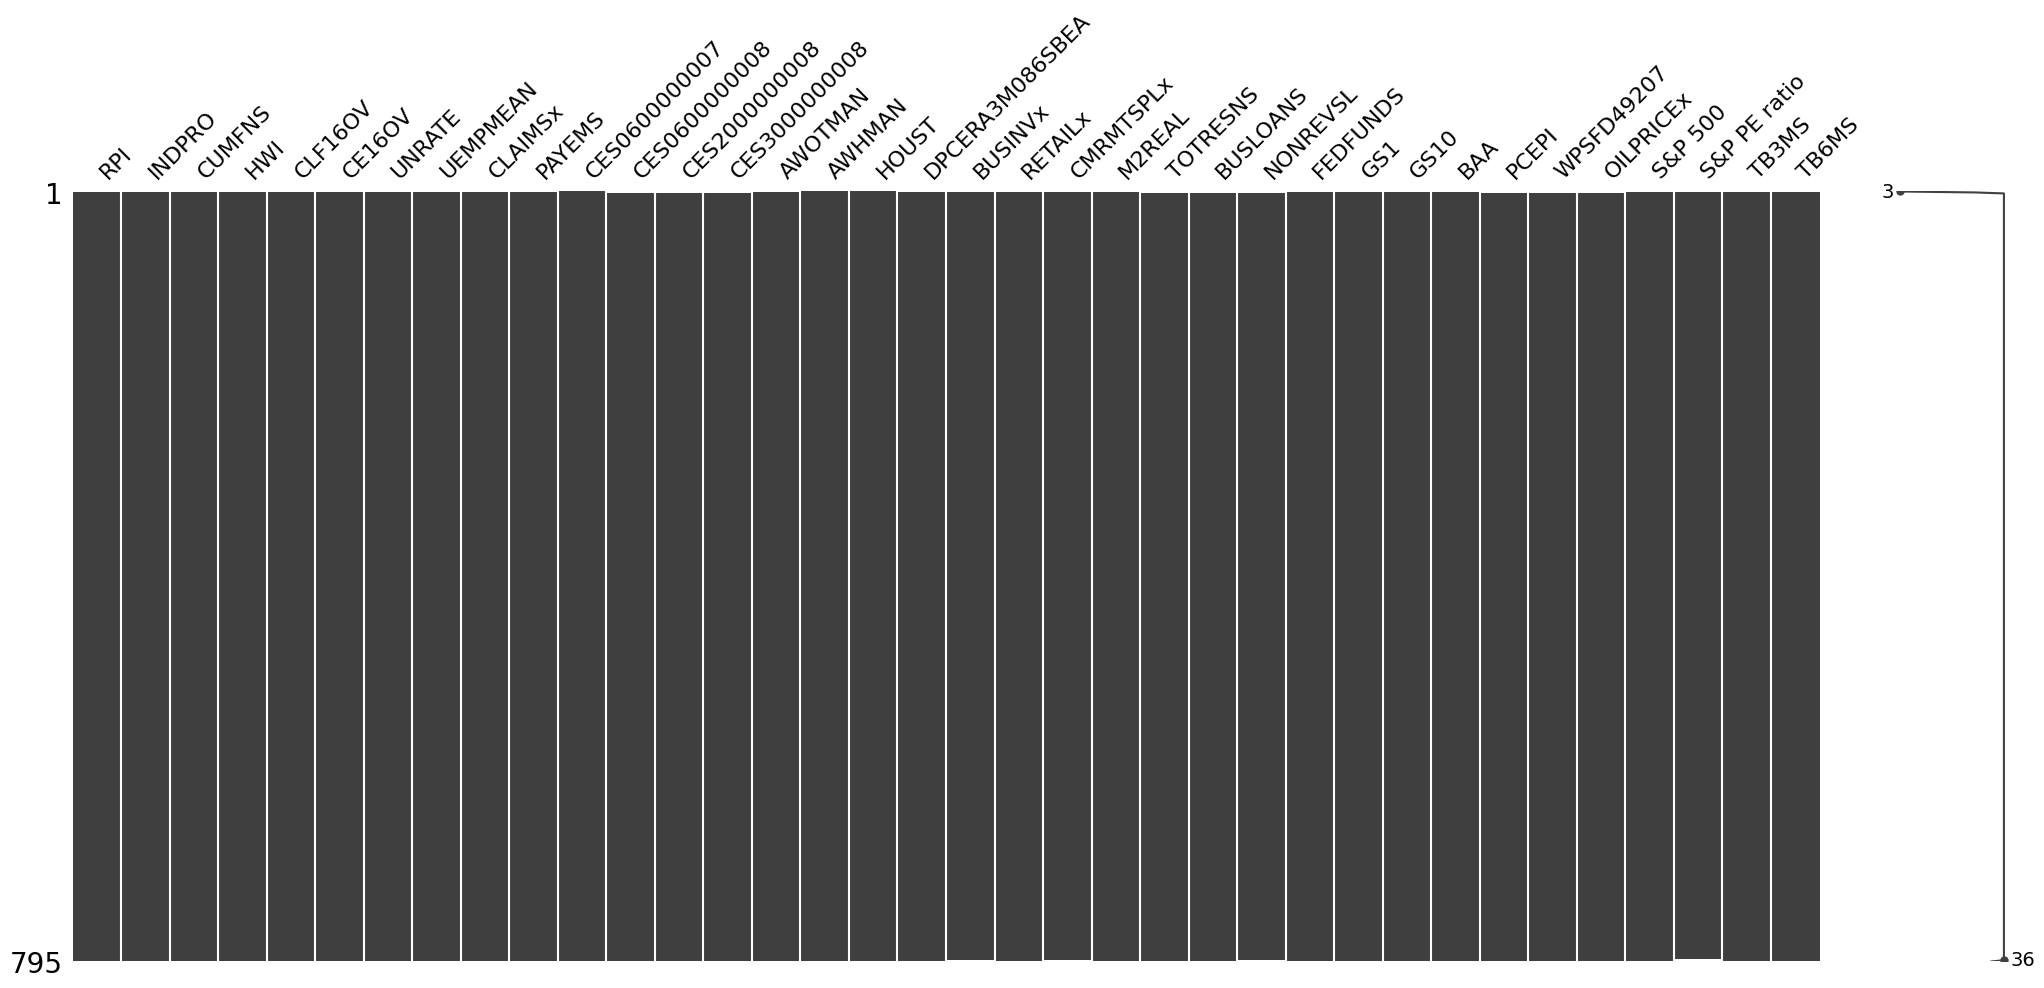

In [110]:
msno.matrix(md[monthly_vars])

In [112]:
md[monthly_vars].ffill().isnull().sum()

RPI                1
INDPRO             1
CUMFNS             1
HWI                1
CLF16OV            1
CE16OV             1
UNRATE             1
UEMPMEAN           1
CLAIMSx            1
PAYEMS             1
CES0600000007      0
CES0600000008      2
CES2000000008      2
CES3000000008      2
AWOTMAN            1
AWHMAN             0
HOUST              0
DPCERA3M086SBEA    1
BUSINVx            1
RETAILx            1
CMRMTSPLx          1
M2REAL             1
TOTRESNS           2
BUSLOANS           2
NONREVSL           2
FEDFUNDS           1
GS1                1
GS10               1
BAA                1
PCEPI              2
WPSFD49207         2
OILPRICEx          2
S&P 500            1
S&P PE ratio       1
TB3MS              1
TB6MS              1
dtype: int64

In [115]:
md[monthly_vars].ffill().dropna()

,RPI,INDPRO,CUMFNS,HWI,CLF16OV,CE16OV,UNRATE,UEMPMEAN,CLAIMSx,PAYEMS,...,GS1,GS10,BAA,PCEPI,WPSFD49207,OILPRICEx,S&P 500,S&P PE ratio,TB3MS,TB6MS
date,,,,,,,,,,,,,,,,,,,,,
1959-03-01,0.006457,0.014300,1.0341,103.0,0.006175,0.009113,-0.3,-0.2,-0.083287,0.006168,...,0.07,0.03,-0.04,-0.000330,-0.003017,-0.010050,0.025062,0.031070,0.10,0.00
1959-04-01,0.006510,0.021080,1.5153,65.0,0.003973,0.007765,-0.4,-0.4,-0.055003,0.005774,...,0.11,0.13,0.01,0.001315,0.000000,0.010050,0.016599,0.014299,0.15,0.14
1959-05-01,0.005796,0.014954,0.9237,66.0,-0.002359,-0.001066,-0.1,-0.2,0.002185,0.004286,...,0.24,0.19,0.10,-0.001448,0.003008,0.000000,0.014949,0.011410,-0.11,0.06
1959-06-01,0.003068,0.001137,-0.1473,62.0,0.001466,0.002316,-0.1,0.2,0.044765,0.002443,...,0.11,0.03,0.08,0.002360,-0.006015,0.000000,-0.008664,-0.020284,0.37,0.19
1959-07-01,-0.000580,-0.024237,-1.7888,6.0,0.003815,0.002495,0.1,-0.6,0.019137,0.002289,...,0.32,0.06,0.04,-0.000792,-0.000009,0.000000,0.038913,0.023100,-0.01,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-01,0.001798,-0.002467,0.0114,416.0,-0.000736,-0.001692,0.1,0.7,-0.073994,0.001647,...,0.13,0.26,0.15,-0.001549,0.008748,-0.053356,0.023478,0.018896,-0.09,0.01
2024-12-01,0.000520,0.011272,0.2854,-523.0,0.001443,0.002961,-0.1,0.1,0.012906,0.002034,...,-0.10,0.03,0.02,0.001892,-0.000612,0.031174,0.013565,0.007865,-0.15,-0.12
2025-01-01,0.002352,0.002171,-0.0242,254.0,0.012951,0.013724,-0.1,-1.7,-0.040166,0.000698,...,-0.05,0.24,0.28,0.000726,-0.002017,0.074671,-0.005236,-0.017328,-0.06,-0.04


In [117]:
quarterly_candidates = [col for col in qd.columns if col not in monthly_vars and col not in ['Unnamed: 0', 'date']]

In [118]:
len(quarterly_candidates)

219

In [120]:
quarterly_candidates

['GDPC1',
 'PCECC96',
 'PCDGx',
 'PCESVx',
 'PCNDx',
 'GPDIC1',
 'FPIx',
 'Y033RC1Q027SBEAx',
 'PNFIx',
 'PRFIx',
 'A014RE1Q156NBEA',
 'GCEC1',
 'A823RL1Q225SBEA',
 'FGRECPTx',
 'SLCEx',
 'EXPGSC1',
 'IMPGSC1',
 'DPIC96',
 'OUTNFB',
 'OUTBS',
 'OUTMS',
 'IPFINAL',
 'IPCONGD',
 'IPMAT',
 'IPDMAT',
 'IPNMAT',
 'IPDCONGD',
 'IPB51110SQ',
 'IPNCONGD',
 'IPBUSEQ',
 'IPB51220SQ',
 'TCU',
 'USPRIV',
 'MANEMP',
 'SRVPRD',
 'USGOOD',
 'DMANEMP',
 'NDMANEMP',
 'USCONS',
 'USEHS',
 'USFIRE',
 'USINFO',
 'USPBS',
 'USLAH',
 'USSERV',
 'USMINE',
 'USTPU',
 'USGOVT',
 'USTRADE',
 'USWTRADE',
 'CES9091000001',
 'CES9092000001',
 'CES9093000001',
 'CIVPART',
 'UNRATESTx',
 'UNRATELTx',
 'LNS14000012',
 'LNS14000025',
 'LNS14000026',
 'UEMPLT5',
 'UEMP5TO14',
 'UEMP15T26',
 'UEMP27OV',
 'LNS13023621',
 'LNS13023557',
 'LNS13023705',
 'LNS13023569',
 'LNS12032194',
 'HOABS',
 'HOAMS',
 'HOANBS',
 'AWHNONAG',
 'HWIx',
 'HOUST5F',
 'PERMIT',
 'HOUSTMW',
 'HOUSTNE',
 'HOUSTS',
 'HOUSTW',
 'RSAFSx',
 'AMDMN

In [121]:
quarterly_targets = [
    "GDPC1",        # Real GDP
    "GPDIC1",       # Gross Private Domestic Investment
    "PCECC96",      # Real Personal Consumption Expenditures
    "DPIC96",       # Disposable Personal Income (Real)
    "OUTNFB",       # Nonfarm Business Sector Output
    "UNRATESTx",    # Short-term Unemployment Rate
    "UNRATELTx",    # Long-term Unemployment Rate
    "PCECTPI",      # PCE Price Index (headline)
    "PCEPILFE",     # Core PCE Price Index
    "CPIAUCSL",     # CPI
    "CPILFESL",     # Core CPI
    "FPIx",         # Fixed Private Investment
    "EXPGSC1",      # Real Exports
    "IMPGSC1"       # Real Imports
]


<Axes: >

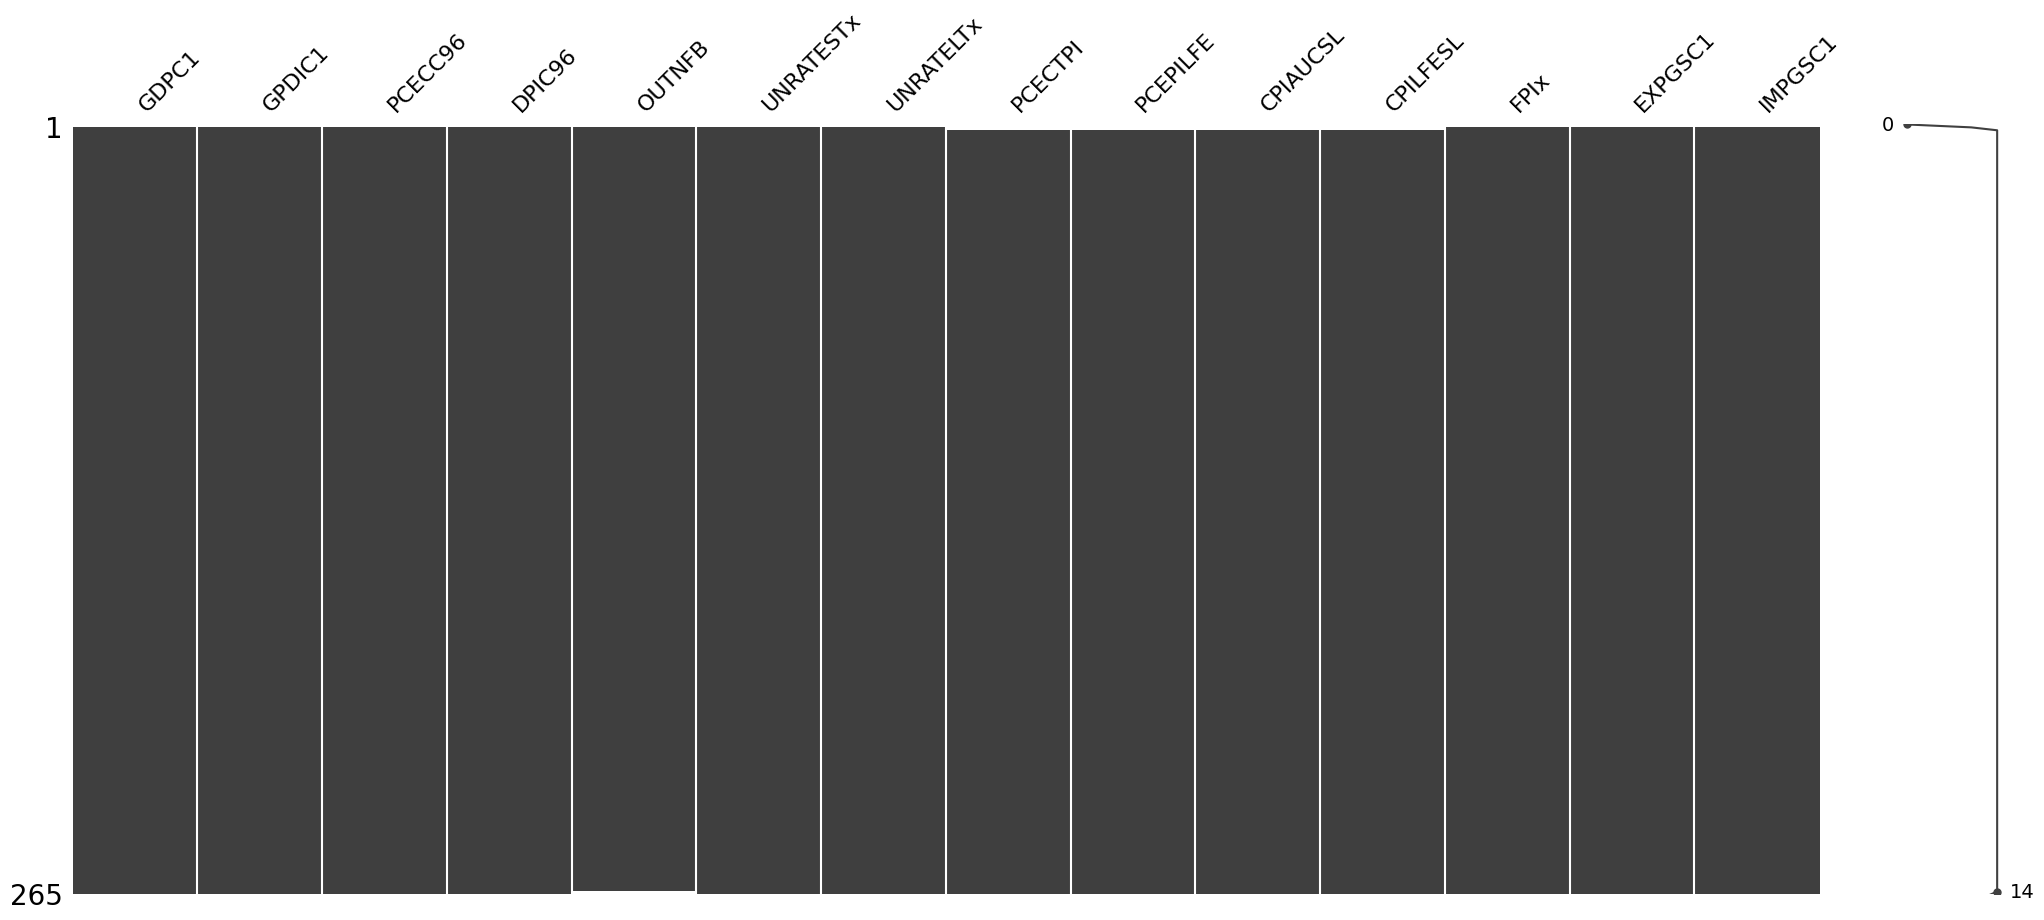

In [127]:
msno.matrix(qd[quarterly_targets])

In [129]:
qd[quarterly_targets].isnull().sum()

GDPC1        1
GPDIC1       1
PCECC96      1
DPIC96       1
OUTNFB       2
UNRATESTx    1
UNRATELTx    1
PCECTPI      2
PCEPILFE     2
CPIAUCSL     2
CPILFESL     2
FPIx         1
EXPGSC1      1
IMPGSC1      1
dtype: int64

In [130]:
qd[quarterly_targets].ffill().isnull().sum()

GDPC1        1
GPDIC1       1
PCECC96      1
DPIC96       1
OUTNFB       1
UNRATESTx    1
UNRATELTx    1
PCECTPI      2
PCEPILFE     2
CPIAUCSL     2
CPILFESL     2
FPIx         1
EXPGSC1      1
IMPGSC1      1
dtype: int64

In [132]:
qd[quarterly_targets]

,GDPC1,GPDIC1,PCECC96,DPIC96,OUTNFB,UNRATESTx,UNRATELTx,PCECTPI,PCEPILFE,CPIAUCSL,CPILFESL,FPIx,EXPGSC1,IMPGSC1
date,,,,,,,,,,,,,,
1959-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-06-01,0.022284,0.074909,0.015326,0.015998,0.028400,-0.463544,-0.230753,NaN,NaN,NaN,NaN,0.030472,-0.008014,0.047511
1959-09-01,0.000697,-0.066760,0.010393,-0.001351,-0.001549,0.346553,-0.164029,0.001942,0.001329,0.003428,-0.001135,0.010525,0.092065,0.009496
1959-12-01,0.002846,0.032025,0.001126,0.007097,-0.002971,0.324653,-0.018279,-0.000555,-0.000949,0.000883,0.002175,-0.011664,-0.050753,-0.025718
1960-03-01,0.022237,0.095789,0.009521,0.011476,0.029316,-0.405583,-0.027543,-0.004168,-0.002554,-0.005126,-0.002220,0.032832,0.121230,0.037076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-01,0.004040,0.008838,0.004773,0.013573,0.003263,0.022019,-0.006219,0.004319,0.004196,0.002206,0.001892,0.015832,0.004744,0.014893
2024-06-01,0.007363,0.020036,0.006938,0.002598,0.007507,0.087578,0.076835,-0.002169,-0.002327,-0.002298,-0.002601,0.005731,0.002572,0.018233
2024-09-01,0.007566,0.001955,0.009088,0.000525,0.008891,0.093206,0.109560,-0.002428,-0.001458,-0.003333,-0.001798,0.005152,0.022933,0.025510


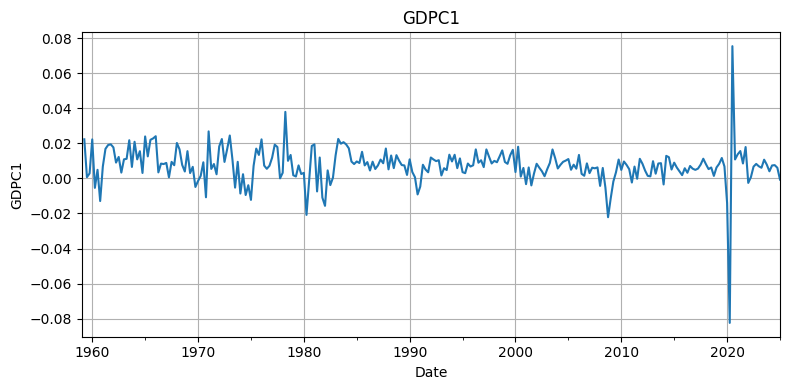

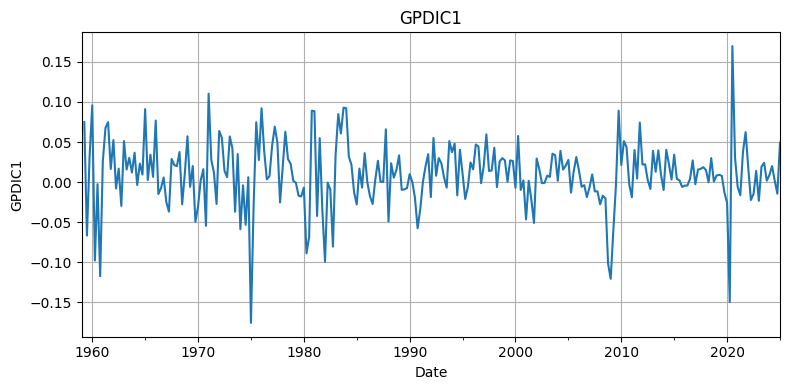

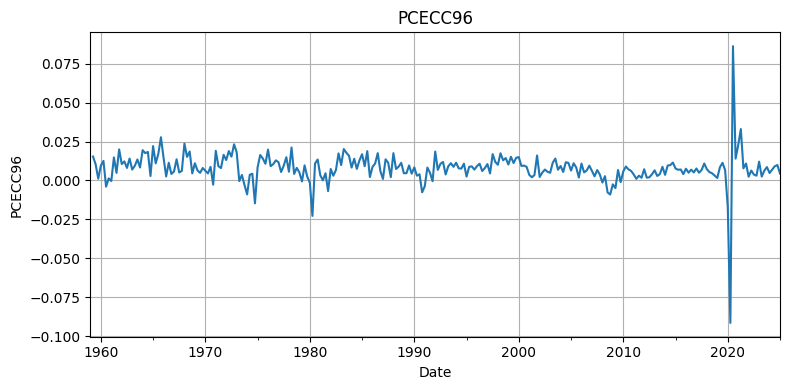

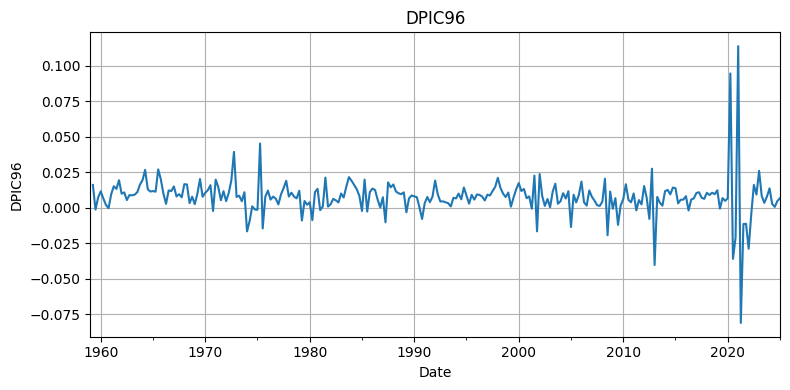

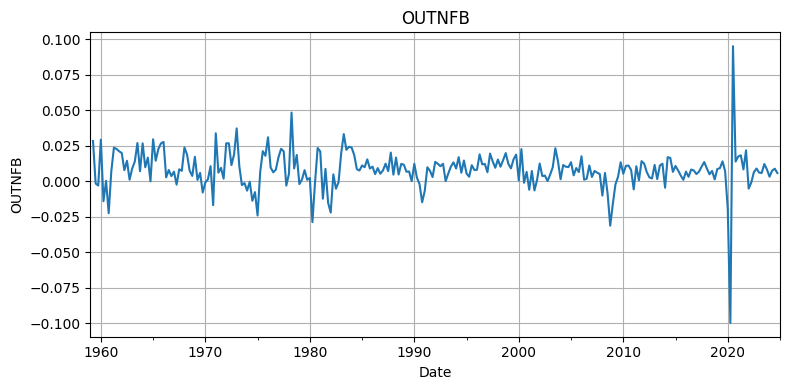

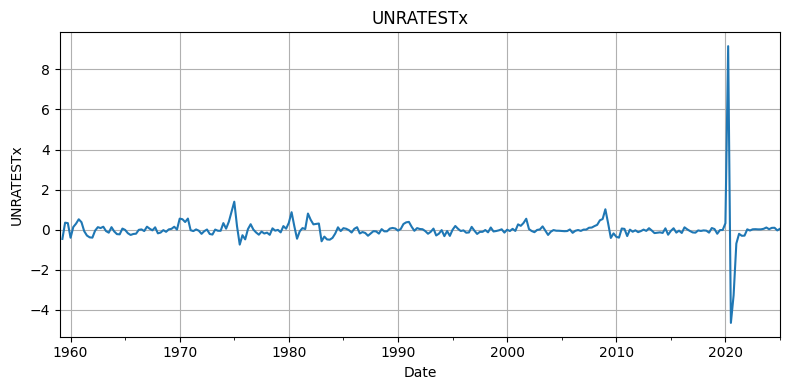

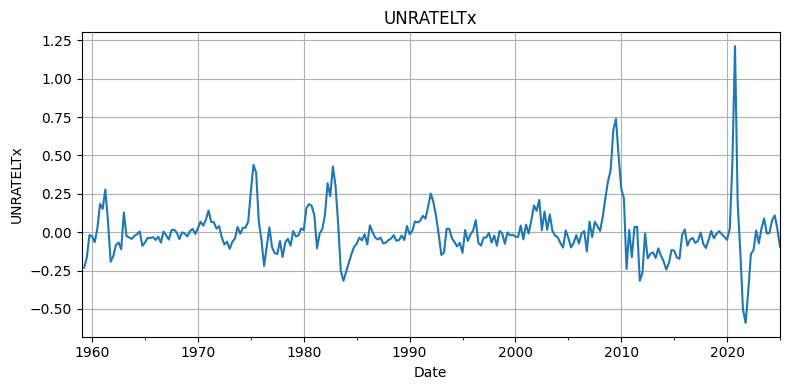

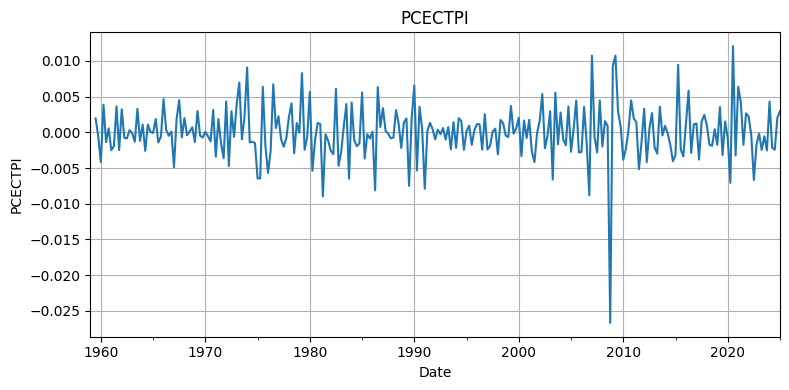

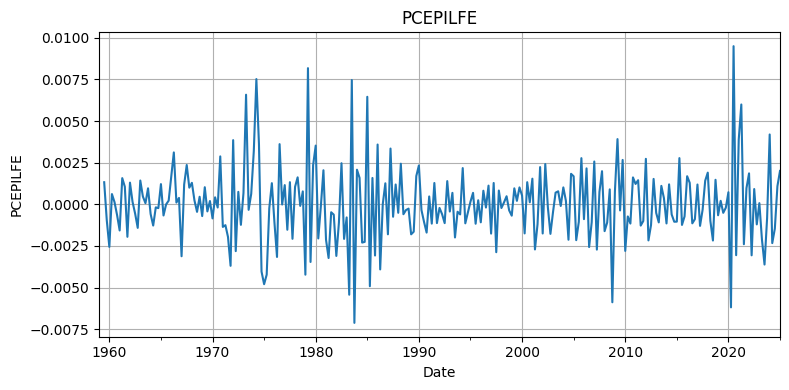

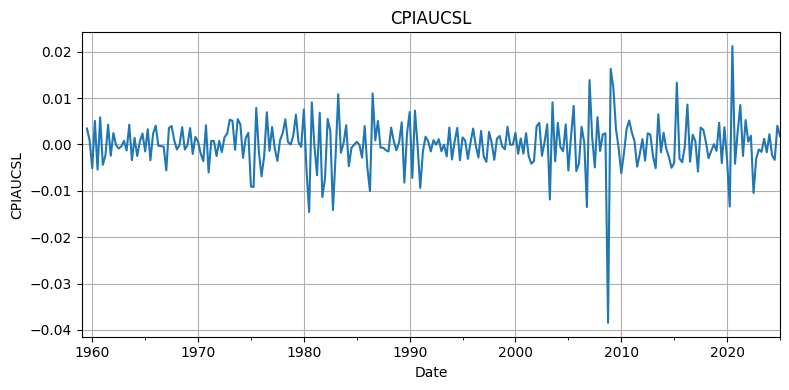

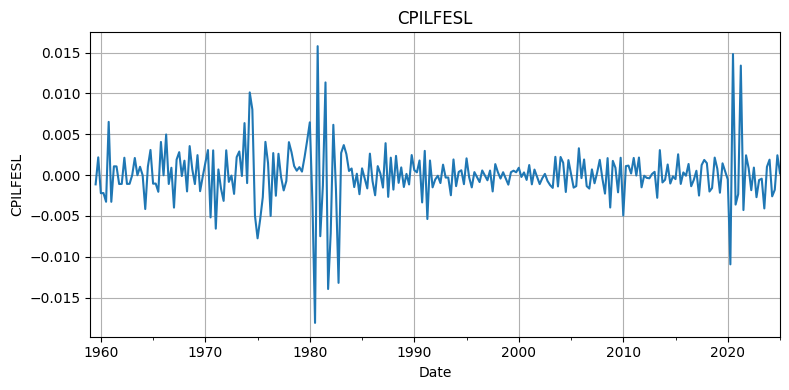

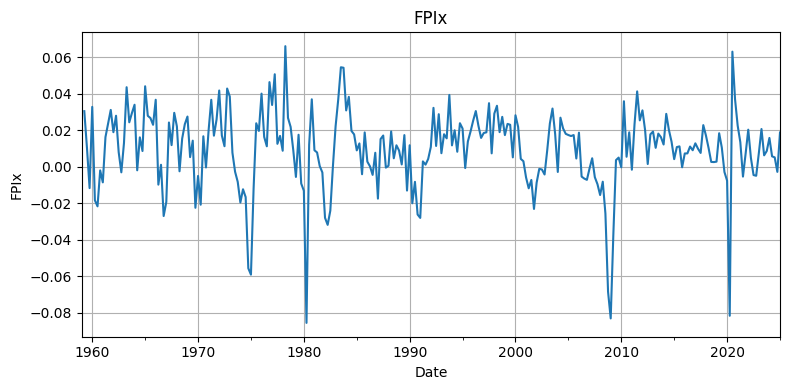

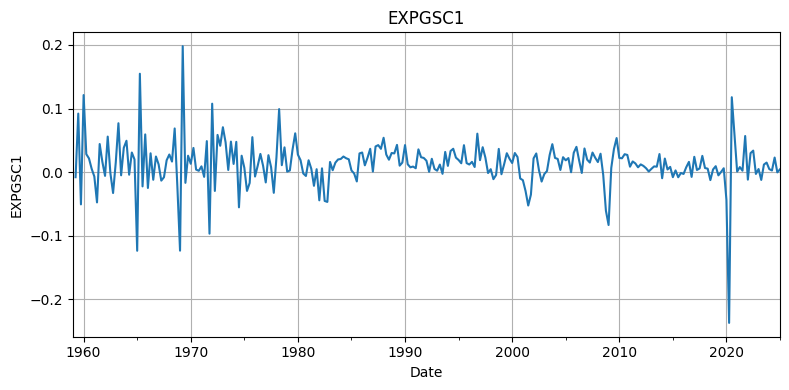

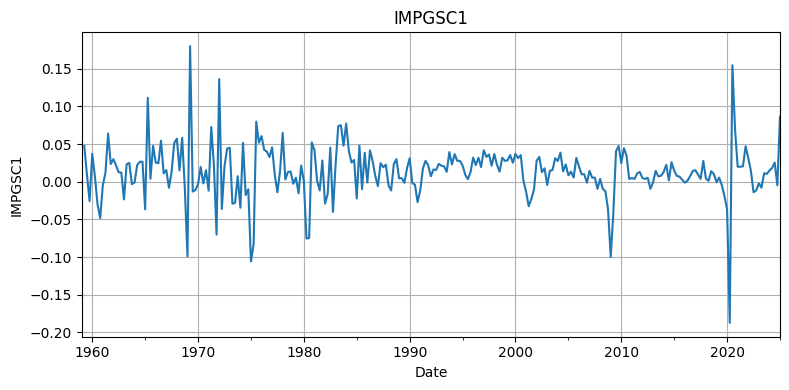

In [136]:
for var in quarterly_targets:
    if var in qd.columns:
        qd[var].plot(title=var, figsize=(8, 4))
        plt.xlabel("Date")
        plt.ylabel(var)
        plt.grid(True)
        plt.tight_layout()
        plt.show()